This compulsory assignment will train, fine-tune and evaluate a Random Forest classifier on the MNIST dataset.

Steps:
1. Import libraries
2. Load the dataset
3. Inspect and understand the data
4. Prepare the data
5. Split into training and test sets
6. Train a baseline Random Forest model
7. Fine-tune the model
8. Evaluate the final model on the test set
9. Summarize and discuss the results

## 1. Import libraries

In [12]:
from sklearn.datasets import fetch_openml
import numpy as np
import matplotlib.pyplot as plt

## 2. Load Dataset

In [13]:
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)

## 3. Inspect and understand the Data

### Check Shape of features and labels

In [14]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("X dtype:", X.dtype)
print("y dtype:", y.dtype)
print(type(X), type(y))

X shape: (70000, 784)
y shape: (70000,)
X dtype: int64
y dtype: object
<class 'numpy.ndarray'> <class 'numpy.ndarray'>


### Check target labels

In [15]:
print("Unique labels:", np.unique(y))

Unique labels: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9']


### Convert labels dtype from object to integer

In [16]:
y = y.astype(int)
print("Unique labels:", np.unique(y))

Unique labels: [0 1 2 3 4 5 6 7 8 9]


### Check class distribution

In [17]:
unique, counts = np.unique(y, return_counts=True)
for label, count in zip(unique, counts):
    print(f"Digit {label}: {count}")

Digit 0: 6903
Digit 1: 7877
Digit 2: 6990
Digit 3: 7141
Digit 4: 6824
Digit 5: 6313
Digit 6: 6876
Digit 7: 7293
Digit 8: 6825
Digit 9: 6958


### Check missing values

In [18]:
print("Missing values in X:", np.isnan(X).sum())
print("Missing values in y:", np.isnan(y).sum() if np.issubdtype(y.dtype, np.number) else "Check not needed for non-numeric y")

Missing values in X: 0
Missing values in y: 0


### Check pixel value range

In [19]:
print("Minimum pixel value:", X.min())
print("Maximum pixel value:", X.max())
print("Mean pixel value:", X.mean())

Minimum pixel value: 0
Maximum pixel value: 255
Mean pixel value: 33.385964741253645


### Visualize a few samples

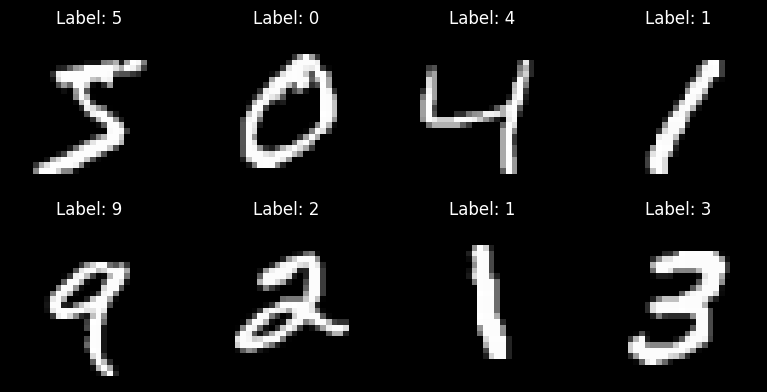

In [20]:
plt.figure(figsize=(8, 4))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(X[i].reshape(28, 28), cmap="gray")
    plt.title(f"Label: {y[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

### Results

The inspection confirmed that the **MNIST** dataset contains **70,000 images**, with each image represented by **784 features**. This corresponds to images of size **28 × 28 pixels**, resulting in **784 pixel values** per sample. The target variable contains **70,000 labels**, representing the digit classes **0 to 9**.

The feature values range from **0 to 255**, where **0 corresponds to black** and 2**55 corresponds to white**, with intermediate values representing shades of gray. This is consistent with grayscale image data.

No missing values were detected in the feature matrix. In addition, the class distribution was found to be reasonably balanced across all ten digit classes, indicating that the dataset is suitable for a classification task.

Since the target labels were initially loaded as objects, they were converted to integers before proceeding to the data preparation stage.


